In [1]:
from IPython.display import Markdown, display

display(Markdown("""
**Ноутбук 3: 03_Baseline_Models.ipynb**

Здесь обучены и сравнены три базовых модели. 

Логистическая регрессия с параметром class_weight='balanced' достигла ROC‑AUC 0,7437 и F1 0,2534, но имела Brier 0,2050. 

Random Forest с аналогичными весами показал ROC‑AUC 0,7178 и очень низкий recall 0,003 (F1 0,0059), что делает его непригодным. 

LightGBM с автоматическим scale_pos_weight, рассчитанным из дисбаланса, дал ROC‑AUC 0,7519 и F1 0,2613, что стало лучшим результатом. 

По ROC‑кривым и метрикам LightGBM выбран лучшей моделью и сохранён как best_model.pkl. Random Forest отброшен, логистическая регрессия оставлена как референс.
"""))


**Ноутбук 3: 03_Baseline_Models.ipynb**

Здесь обучены и сравнены три базовых модели. 

Логистическая регрессия с параметром class_weight='balanced' достигла ROC‑AUC 0,7437 и F1 0,2534, но имела Brier 0,2050. 

Random Forest с аналогичными весами показал ROC‑AUC 0,7178 и очень низкий recall 0,003 (F1 0,0059), что делает его непригодным. 

LightGBM с автоматическим scale_pos_weight, рассчитанным из дисбаланса, дал ROC‑AUC 0,7519 и F1 0,2613, что стало лучшим результатом. 

По ROC‑кривым и метрикам LightGBM выбран лучшей моделью и сохранён как best_model.pkl. Random Forest отброшен, логистическая регрессия оставлена как референс.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, precision_recall_fscore_support,
    classification_report, roc_curve
)

np.random.seed(42)

Загрузка данных

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')

y_train = pd.read_csv('../data/processed/y_train_lin.csv').values.ravel()
y_val = pd.read_csv('../data/processed/y_val_lin.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test_lin.csv').values.ravel()

preprocessor = joblib.load('../artifacts/preprocessor.pkl')

print(f"Размеры: X_train {X_train.shape}, y_train {len(y_train)}")
print(f"Размеры: X_val {X_val.shape}, y_val {len(y_val)}")
print(f"Размеры: X_test {X_test.shape}, y_test {len(y_test)}")
print(f"Распределение классов в train: {np.bincount(y_train)}")

Размеры: X_train (215257, 65), y_train 215257
Размеры: X_val (46127, 65), y_val 46127
Размеры: X_test (46127, 65), y_test 46127
Распределение классов в train: [197880  17377]


Трансформация данных

In [3]:
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Размер после трансформации: train {X_train_processed.shape}, val {X_val_processed.shape}, test {X_test_processed.shape}")

Размер после трансформации: train (215257, 168), val (46127, 168), test (46127, 168)


Логистическая регрессия

In [4]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_processed, y_train)

# Предсказания вероятностей и классов
y_val_proba_lr = lr.predict_proba(X_val_processed)[:, 1]
y_val_pred_lr = lr.predict(X_val_processed)

# Метрики
roc_auc_lr = roc_auc_score(y_val, y_val_proba_lr)
brier_lr = brier_score_loss(y_val, y_val_proba_lr)
precision_lr, recall_lr, f1_lr, _ = precision_recall_fscore_support(y_val, y_val_pred_lr, average='binary')

print("Logistic Regression")
print(f"ROC-AUC: {roc_auc_lr:.4f}")
print(f"Brier score: {brier_lr:.4f}")
print(f"Precision: {precision_lr:.4f}, Recall: {recall_lr:.4f}, F1: {f1_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_lr, target_names=['No Default', 'Default']))

Logistic Regression
ROC-AUC: 0.7437
Brier score: 0.2050
Precision: 0.1565, Recall: 0.6651, F1: 0.2534

Classification Report:
              precision    recall  f1-score   support

  No Default       0.96      0.69      0.80     42403
     Default       0.16      0.67      0.25      3724

    accuracy                           0.68     46127
   macro avg       0.56      0.68      0.53     46127
weighted avg       0.89      0.68      0.76     46127



Random Forest

In [5]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_processed, y_train)

y_val_proba_rf = rf.predict_proba(X_val_processed)[:, 1]
y_val_pred_rf = rf.predict(X_val_processed)

roc_auc_rf = roc_auc_score(y_val, y_val_proba_rf)
brier_rf = brier_score_loss(y_val, y_val_proba_rf)
precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(y_val, y_val_pred_rf, average='binary')

print("Random Forest")
print(f"ROC-AUC: {roc_auc_rf:.4f}")
print(f"Brier score: {brier_rf:.4f}")
print(f"Precision: {precision_rf:.4f}, Recall: {recall_rf:.4f}, F1: {f1_rf:.4f}")

Random Forest
ROC-AUC: 0.7178
Brier score: 0.0697
Precision: 0.5238, Recall: 0.0030, F1: 0.0059


LightGBM (с учётом дисбаланса)

In [6]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

lgb = LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1)
lgb.fit(X_train_processed, y_train)

y_val_proba_lgb = lgb.predict_proba(X_val_processed)[:, 1]
y_val_pred_lgb = lgb.predict(X_val_processed)

roc_auc_lgb = roc_auc_score(y_val, y_val_proba_lgb)
brier_lgb = brier_score_loss(y_val, y_val_proba_lgb)
precision_lgb, recall_lgb, f1_lgb, _ = precision_recall_fscore_support(y_val, y_val_pred_lgb, average='binary')

print("LightGBM")
print(f"ROC-AUC: {roc_auc_lgb:.4f}")
print(f"Brier score: {brier_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}, Recall: {recall_lgb:.4f}, F1: {f1_lgb:.4f}")

LightGBM
ROC-AUC: 0.7519
Brier score: 0.1943
Precision: 0.1622, Recall: 0.6702, F1: 0.2613


C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Сравнение моделей

Сравнение моделей (валидация):
                 Model  ROC-AUC   Brier  Precision  Recall      F1
0  Logistic Regression   0.7437  0.2050     0.1565  0.6651  0.2534
1        Random Forest   0.7178  0.0697     0.5238  0.0030  0.0059
2             LightGBM   0.7519  0.1943     0.1622  0.6702  0.2613


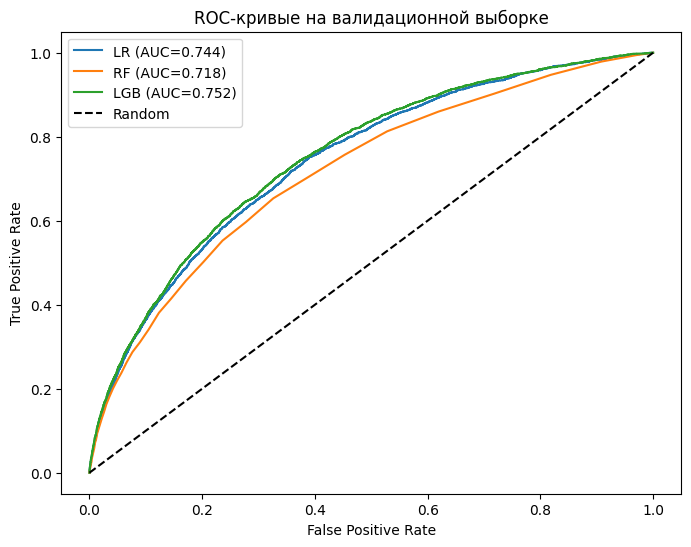

In [7]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM'],
    'ROC-AUC': [roc_auc_lr, roc_auc_rf, roc_auc_lgb],
    'Brier': [brier_lr, brier_rf, brier_lgb],
    'Precision': [precision_lr, precision_rf, precision_lgb],
    'Recall': [recall_lr, recall_rf, recall_lgb],
    'F1': [f1_lr, f1_rf, f1_lgb]
})
print("Сравнение моделей (валидация):")
print(results.round(4))

# ROC-кривые
plt.figure(figsize=(8, 6))
for name, proba in [('LR', y_val_proba_lr), ('RF', y_val_proba_rf), ('LGB', y_val_proba_lgb)]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_val, proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые на валидационной выборке')
plt.legend()
plt.show()

Сохранение лучшей модели

In [8]:
best_model = lgb
joblib.dump(best_model, '../artifacts/best_model.pkl')
print("Модель LightGBM сохранена как лучшая в '../artifacts/best_model.pkl'")

Модель LightGBM сохранена как лучшая в '../artifacts/best_model.pkl'
